In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import ones,copy,cos,tan,pi,linspace
def cart_2_polar(x,y):
    r=np.sqrt(x**2+y**2)
    phi=np.arctan2(y,x)
    return r,phi
def gaussxw(N):

    # Initial approximation to roots of the Legendre polynomial
    a = linspace(3,4*N-1,N)/(4*N+2)
    x = cos(pi*a+1/(8*N*N*tan(a)))

    # Find roots using Newton's method
    epsilon = 1e-15
    delta = 1.0
    while delta>epsilon:
        p0 = ones(N,float)
        p1 = copy(x)
        for k in range(1,N):
            p0,p1 = p1,((2*k+1)*x*p1-k*p0)/(k+1)
        dp = (N+1)*(p0-x*p1)/(1-x*x)
        dx = p1/dp
        x -= dx
        delta = max(abs(dx))

    # Calculate the weights
    w = 2*(N+1)*(N+1)/(N*N*(1-x*x)*dp*dp)

    return x,w

def gaussxwab(N,a,b):
    x,w = gaussxw(N)
    return 0.5*(b-a)*x+0.5*(b+a),0.5*(b-a)*w
def integral2d(a,b,c,d,N,M,f):
    x,w=gaussxwab(N,a,b)
    y,v=gaussxwab(M,c,d)
    I=0
    for i in range(N):
        for j in range(M):
            I+=w[i]*v[j]*f(x[i],y[j])
    return I
integral2d=np.vectorize(integral2d)

# Práctica 1: Obteniendo el potencial y el campo eléctrico a partir de una distribución de carga

Por la 1ª ley de Maxwell, se tiene que una distribución de carga $\rho$ genera un potencial eléctrico $\phi$

$$\nabla^2 \phi(\textbf{r})=-\frac{\rho(\textbf{r})}{\epsilon_0},$$

que, en coordenadas cartesianas en dos dimensiones, toma la forma

$$\left(\frac{\partial^2}{\partial x^2}+\frac{\partial^2}{\partial y^2}\right) \phi(x,y)=-\frac{\rho(x,y)}{\epsilon_0}.$$

Veremos cómo resolver esta ecuación en derivadas parciales (EDP) en el Tema 8. Sin embargo, puede obtenerse la solución de la ecuación a partir de la función de Green asociada, es decir, resolviendo la siguiente integral extendida a todo el espacio

$$\phi(\textbf{r})=\frac{1}{4 \pi \epsilon_0}\int\int \frac{\rho(\textbf{r'})}{|\textbf{r}-\textbf{r'}|}d^2\textbf{r'}.$$

1. **[2 pts]** Dada la siguiente distribución de carga bidimensional en polares,

    $$\rho(r,\varphi)=
  \left\{ 
    \begin{array}{cc}
      \rho_0e^{-\frac{1}{1-r^3}}\sin(8\varphi) &\hspace{5mm} 0\leq r <1 , \hspace{5mm} 0\leq \varphi \leq2\pi \\
      0 & \hspace{5mm} \text{en otro caso}
    \end{array} \right.
    \,,$$

    con $\rho_0=100 \, \text{C}\,\text{m}^{-3}$, representarla para $-1\leq x\leq 1$, $-1\leq y\leq 1$ (coordenadas cartesianas) en un grid $1000\times 1000$. 
    
    $\textbf{Ayuda:}$ 
    - Para ello, podría ser de ayuda utilizar el comando $\textbf{vectorize}$.
    - Para calcular de forma correcta $\arctan(y/x)$, se recomienda el uso de la función $\textbf{arctan2(y,x)}$ de $\textbf{numpy}$.
    - Se recomienda utilizar el patrón de color $\textbf{seismic}$ de $\textbf{imshow}$.

/tmp/ipykernel_128/132666170.py:8: RuntimeWarning: overflow encountered in power
  return np.where((r<1)&(phi<2*np.pi),ro0*np.e**(-1/(1-r**3))*np.sin(8*phi),0)


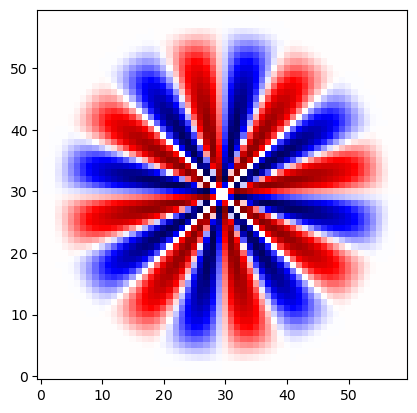

In [14]:
ro0=100
N=60
x=np.linspace(-1,1,N)
y=np.linspace(-1,1,N)
x,y=np.meshgrid(x,y)
R,phi=cart_2_polar(x,y)
def f(r,phi):
    return np.where((r<1)&(phi<2*np.pi),ro0*np.e**(-1/(1-r**3))*np.sin(8*phi),0)
ro=f(r,phi)
plt.imshow(ro,cmap='seismic',origin='lower')

2. **[3,5 pts]** Definir una función que proporcione el potencial eléctrico $\phi$ generado por la distribución de carga del apartado anterior (recuerda que $\epsilon_0=8.85\times 10^{-12}\,\text{C}^2\,\text{N}^{-1}\,\text{m}^{-2}$). Justificar el método de integración utilizado.

    $\textbf{Ayuda:}$ 
    - Integrar la distribución de carga en el dominio donde es distinta de $0$, no en todo el espacio.
    - Si se calcula la integral en polares, prestar atención al elemento diferencial de superficie.

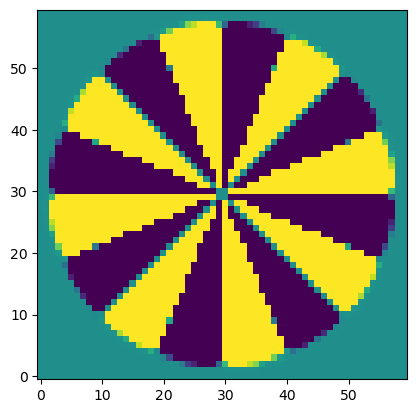

In [12]:
e0=8.85*10**-12


def pot(ro):
    def g(r,phi):
        return np.where(ro!=0,r*ro/abs(R-r),0)
    V=np.where(ro!=0,integral2d(0,1,0,2*np.pi,60,60,g)/(4*np.pi*e0),0)
    return V

plt.imshow(pot(ro),vmin=-10**11,vmax=10**11,origin='lower')

3. **[1 pt]** Representar el potencial eléctrico para $-2\leq x\leq 2$, $-2\leq y\leq 2$ en un grid $200\times 200$ (se recomienda utilizar $v_{max}=10^{11}\,$V y $v_{min}=-10^{11}\,$V en $\textbf{imshow}$).

4. **[2,5 pts]** A partir del potencial eléctrico, puede calcularse el campo eléctrico, en un régimen electrostático, de la siguiente forma

    $$\textbf{E}=- \boldsymbol{\nabla} \phi,$$

    que en coordenadas cartesianas bidimensionales, toma la forma
    
    $$E_x=-\frac{\partial \phi}{\partial x} \hspace{3mm},\hspace{3mm}E_y=-\frac{\partial \phi}{\partial y}.$$
    
    Calcular el campo eléctrico en $-2\leq x\leq 2$, $-2\leq y\leq 2$ a partir de la función definida en el apartado 2 (es decir, el potencial eléctrico $\phi$) en un grid $60\times 60$.

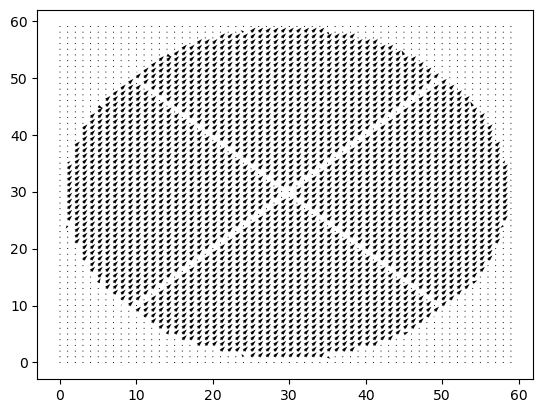

In [8]:
h=10**-6
R=r
def dr(r,phi):
    return np.where(ro!=0,(f(r+h,phi)/abs(R-r+h)-ro/abs(R-r))/h,0)
def dphi(r,phi):
    return np.where(ro!=0,(f(r,phi+h)/abs(R-r)-ro/abs(R-r))/h,0)
Ex=-np.cos(phi)*r*integral2d(0,1,0,2*np.pi,60,60,dr)/(4*np.pi*e0)+np.sin(phi)*r*integral2d(0,1,0,2*np.pi,60,60,dphi)/(4*np.pi*e0)
Ey=-np.sin(phi)*r*integral2d(0,1,0,2*np.pi,60,60,dr)/(4*np.pi*e0)-np.cos(phi)*r*integral2d(0,1,0,2*np.pi,60,60,dphi)/(4*np.pi*e0)

C=10**11
Ex=np.where(abs(Ex)>C,C,Ex)
Ey=np.where(abs(Ey)>C,C,Ey)
plt.quiver(Ex,Ey)



5. **[1 pt]** Representar el campo eléctrico calculado en el apartado anterior mediante el comando $\textbf{quiver}$ del paquete $\textbf{matplotlib.pyplot}$ (una vez calculados $E_x$ y $E_y$, basta hacer uso de $\textbf{quiver}(E_x,E_y)$).

6. **[Extra: 1 pt]** Si has llegado al resultado correcto, observarás que el campo tiene una simetría parecida a la distribución de carga, pero en algunos puntos el módulo del campo eléctrico es muy elevado. Ello ocurre cuando se calcula $\phi$ en un punto muy cercano a uno de los puntos donde se evalúa el integrando, de forma que éste se vuelve muy grande y puede haber errores numéricos. Vuelve a representar $E_x$ y $E_y$, pero esta vez cuando $|E_{x,y}|>C$ (por ejemplo, $C=10^{11}\, \text{N}\,\text{C}^{-1}$), sustituye $|E_{x,y}|=C$, y obtendrás el mismo resultado que en el apartado anterior, pero evitando los errores numéricos.